In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\saeek\Downloads\socbiz\notebooks\urbanev_cleaned_processed.csv", parse_dates=["datetime"])
print(f"  Rows: {len(df):,}  |  Columns: {len(df.columns)}")

  Rows: 2,134,080  |  Columns: 37


In [4]:
FEATURES = [
    # Temporal features — charging patterns vary by time
    "hour_of_day","day_of_week","is_weekend",       
    "month","is_peak","hour_float",
 
    # Historical demand — the most important predictor
    "lag_1","lag_12","lag_288","rolling_3",   
 
    # District characteristics 
    "total_chargers","fast_count","slow_count",    
    "CBD","dynamic_pricing","area",           
]

In [5]:
TARGET_REG  = "utilization_rate"  
TARGET_CLF  = "congestion_flag"

In [10]:
df["is_peak"] = (df["peak_period"] != "Off-Peak").astype(int)

In [11]:
df_model = df[FEATURES + [TARGET_REG, TARGET_CLF, "datetime", "district_id"]].dropna()

In [13]:
print(f"  Rows after dropping NaN: {len(df_model):,}")

  Rows after dropping NaN: 2,134,080


TRAIN TEST SPLIT

In [14]:
df_model = df_model.sort_values("datetime").reset_index(drop=True)

In [15]:
cutoff = df_model["datetime"].quantile(0.80)
print(f"  Train: data before {cutoff.date()}")
print(f"  Test : data from   {cutoff.date()} onwards")

  Train: data before 2022-07-12
  Test : data from   2022-07-12 onwards


In [16]:
from sklearn.model_selection import train_test_split
 
train = df_model[df_model["datetime"] <= cutoff]
test  = df_model[df_model["datetime"] >  cutoff]

In [18]:
X_train = train[FEATURES]
y_train_reg = train[TARGET_REG]
y_train_clf = train[TARGET_CLF]
 
X_test  = test[FEATURES]
y_test_reg  = test[TARGET_REG]
y_test_clf  = test[TARGET_CLF]

 Training XGBoost regression model

In [ ]:
from xgboost import XGBRegressor, XGBClassifier
reg_model = XGBRegressor(
    n_estimators= 300,max_depth = 6,learning_rate= 0.08,
    subsample= 0.8,
    colsample_bytree= 0.8,random_state= 42,
    n_jobs= -1,eval_metric= "rmse"
)

In [20]:
reg_model.fit(
    X_train, y_train_reg,
    eval_set=[(X_test, y_test_reg)],
  
)

[0]	validation_0-rmse:0.16328
[1]	validation_0-rmse:0.15031
[2]	validation_0-rmse:0.13841
[3]	validation_0-rmse:0.12744
[4]	validation_0-rmse:0.11735
[5]	validation_0-rmse:0.10807
[6]	validation_0-rmse:0.09959
[7]	validation_0-rmse:0.09176
[8]	validation_0-rmse:0.08460
[9]	validation_0-rmse:0.07798
[10]	validation_0-rmse:0.07192
[11]	validation_0-rmse:0.06638
[12]	validation_0-rmse:0.06128
[13]	validation_0-rmse:0.05659
[14]	validation_0-rmse:0.05229
[15]	validation_0-rmse:0.04835
[16]	validation_0-rmse:0.04475
[17]	validation_0-rmse:0.04146
[18]	validation_0-rmse:0.03845
[19]	validation_0-rmse:0.03570
[20]	validation_0-rmse:0.03323
[21]	validation_0-rmse:0.03098
[22]	validation_0-rmse:0.02890
[23]	validation_0-rmse:0.02701
[24]	validation_0-rmse:0.02530
[25]	validation_0-rmse:0.02378
[26]	validation_0-rmse:0.02239
[27]	validation_0-rmse:0.02115
[28]	validation_0-rmse:0.02005
[29]	validation_0-rmse:0.01908
[30]	validation_0-rmse:0.01816
[31]	validation_0-rmse:0.01735
[32]	validation_0-

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

REGRESSION EVALUATION

In [21]:
y_pred_reg = reg_model.predict(X_test)
y_pred_reg = np.clip(y_pred_reg, 0, 1)

In [22]:
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score,classification_report,confusion_matrix)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae  = mean_absolute_error(y_test_reg, y_pred_reg)
r2   = r2_score(y_test_reg, y_pred_reg)

In [24]:
print(f"\n  REGRESSION METRICS (Demand Prediction Agent):")
print(f"  {'RMSE':<30}: {rmse:.4f}")
print(f"  {'MAE':<30}: {mae:.4f} ")
print(f"  {'R² Score':<30}: {r2:.4f}  ")


  REGRESSION METRICS (Demand Prediction Agent):
  RMSE                          : 0.0115
  MAE                           : 0.0051 
  R² Score                      : 0.9958  


R2 SCORE IS CLOSER TO ONE ,SO IT IS GOOD
MOREOVER RMSE AND MAE IS NEAR TO 0 SO THAT IS ALSO GOOG

Training XGBoost classifier (congestion flag)

In [25]:
n_congested = y_train_clf.sum()
n_normal    = len(y_train_clf) - n_congested
print(f"  Training set: {n_congested:,} congested, {n_normal:,} normal")
print(f"  Class balance: {n_congested/len(y_train_clf):.1%} congested")

  Training set: 17,456 congested, 1,689,808 normal
  Class balance: 1.0% congested


In [26]:
scale_pos = n_normal / max(n_congested, 1)
 

In [ ]:
clf_model = XGBClassifier(
    n_estimators= 300,max_depth = 6,learning_rate = 0.08,subsample= 0.8,colsample_bytree = 0.8,
 scale_pos_weight  = scale_pos,   # handles class imbalance
random_state = 42,n_jobs= -1, eval_metric = "logloss")
   


In [28]:
clf_model.fit(
    X_train, y_train_clf,
    eval_set=[(X_test, y_test_clf)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [30]:
y_pred_clf = clf_model.predict(X_test)
y_pred_proba = clf_model.predict_proba(X_test)[:, 1]  # probability of congestion
 
print("\n  CLASSIFICATION METRICS (Congestion Prediction):")
print(classification_report(y_test_clf, y_pred_clf,target_names=["Normal", "Congested"]))


  CLASSIFICATION METRICS (Congestion Prediction):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    422398
   Congested       0.81      0.99      0.89      4418

    accuracy                           1.00    426816
   macro avg       0.90      0.99      0.94    426816
weighted avg       1.00      1.00      1.00    426816



In [35]:
test_results = test[["datetime", "district_id", "utilization_rate", "congestion_flag"]].copy()


test_results["predicted_utilization"]     = y_pred_reg
test_results["predicted_congestion_flag"] = y_pred_clf
test_results["congestion_probability"]    = y_pred_proba
test_results["prediction_error"]          = (
    test_results["predicted_utilization"] - test_results["utilization_rate"]
)
 
test_results.to_csv("outputs/demand_predictions.csv", index=False)
print("Saved to outputs/demand_predictions.csv")

Saved to outputs/demand_predictions.csv


In [36]:
metrics_df = pd.DataFrame({
    "Agent":   ["Demand Prediction Agent"] * 3,
    "Metric":  ["RMSE", "MAE", "R²"],
    "Value":   [rmse, mae, r2]
})
metrics_df.to_csv("outputs/demand_model_metrics.csv", index=False)
print(" Saved to outputs/demand_model_metrics.csv")

 Saved to outputs/demand_model_metrics.csv


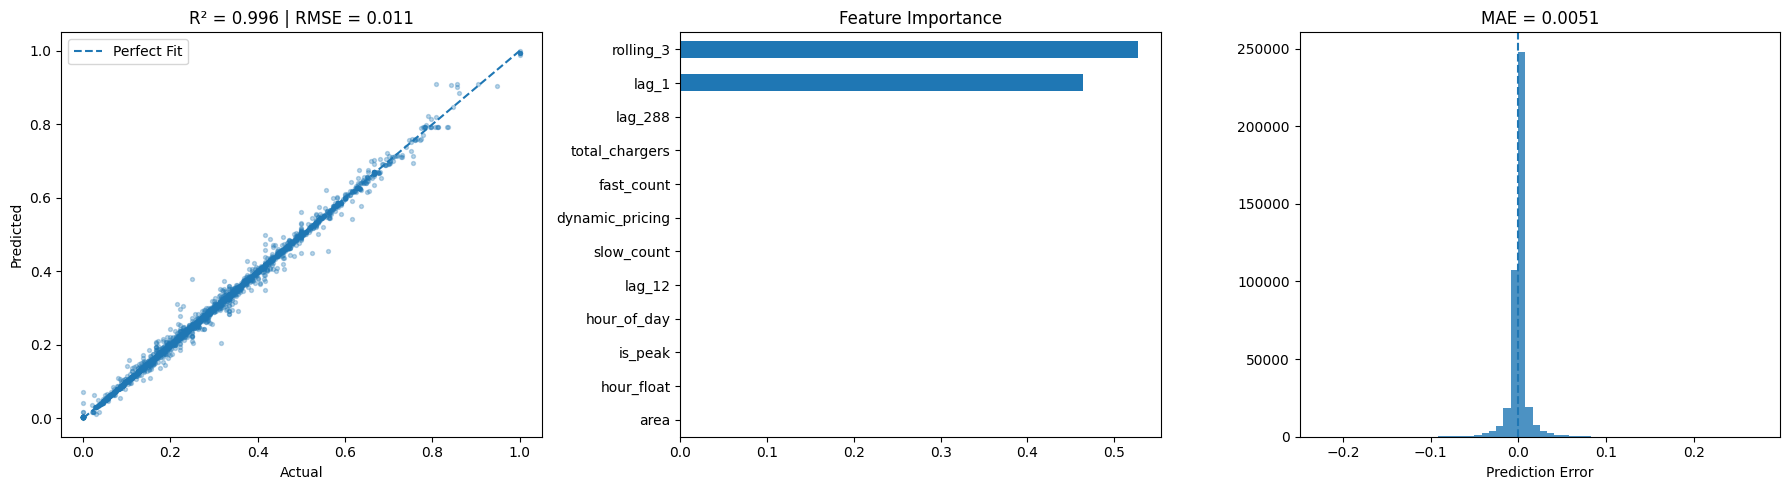

 Saved chart 


<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]

idx = np.random.choice(len(y_test_reg), min(3000, len(y_test_reg)), replace=False)

ax.scatter(
    y_test_reg.iloc[idx],y_pred_reg[idx],alpha=0.3,s=8
)

ax.plot([0, 1], [0, 1], "--", label="Perfect Fit")

ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title(f"R² = {r2:.3f} | RMSE = {rmse:.3f}")
ax.legend()

ax = axes[1]

importance = pd.Series(
    reg_model.feature_importances_,
    index=FEATURES
).sort_values().tail(12)

importance.plot(kind="barh", ax=ax)

ax.set_title("Feature Importance")

ax = axes[2]

errors = y_pred_reg - y_test_reg

ax.hist(errors, bins=60, alpha=0.8)

ax.axvline(0, linestyle="--")
ax.set_xlabel("Prediction Error")
ax.set_title(f"MAE = {mae:.4f}")

plt.tight_layout()
plt.show()
plt.savefig("outputs/charts/10_demand_model_eval.png", dpi=150,
            bbox_inches="tight")

print(" Saved chart ")

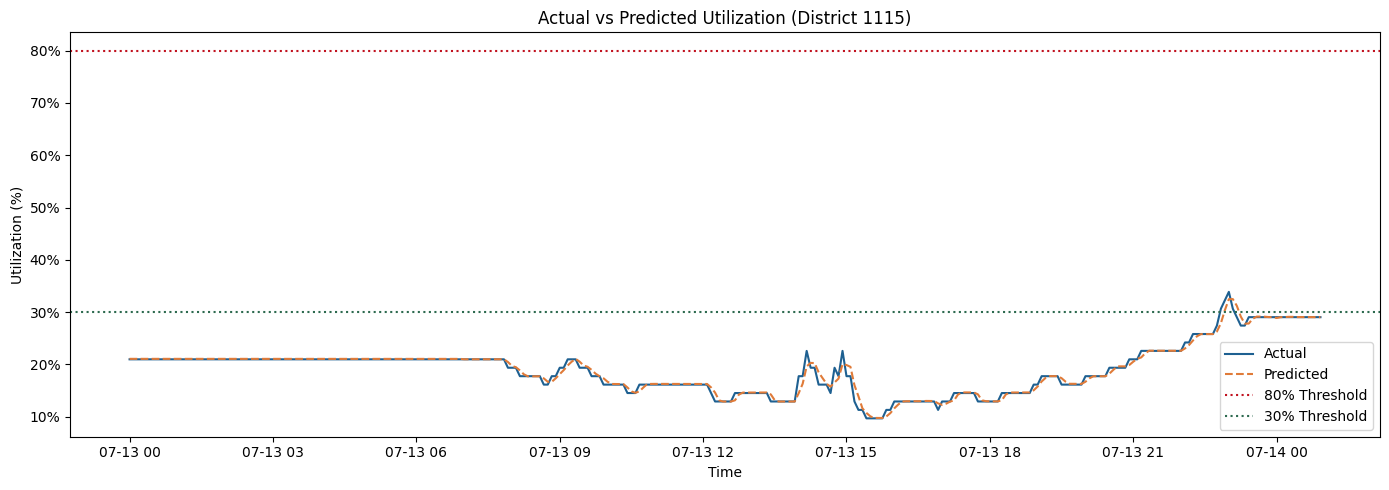

 Saved chart 11


<Figure size 640x480 with 0 Axes>

In [41]:
fig, ax = plt.subplots(figsize=(14, 5))

best_district = test_results["district_id"].value_counts().idxmax()

district_ts = (
    test_results[test_results["district_id"] == best_district]
    .sort_values("datetime")
    .head(300)
)

ax.plot(
    district_ts["datetime"],
    district_ts["utilization_rate"] * 100,
    color= "#1e6091",label="Actual"
)

ax.plot(
    district_ts["datetime"],
    district_ts["predicted_utilization"] * 100,
    color="#e07b39",linestyle="--",label="Predicted"
)

ax.axhline(80, color="#c1121f", linestyle=":", label="80% Threshold")
ax.axhline(30, color="#2d6a4f", linestyle=":", label="30% Threshold")

ax.set_xlabel("Time")
ax.set_ylabel("Utilization (%)")
ax.set_title(f"Actual vs Predicted Utilization (District {best_district})")

import matplotlib.ticker as mtick
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()
plt.savefig("outputs/charts/11_demand_time_series.png", dpi=150)
print(" Saved chart 11")

In [43]:
print("DEMAND AGENT COMPLETE")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")


DEMAND AGENT COMPLETE
  RMSE : 0.0115
  MAE  : 0.0051
  R²   : 0.9958
